# Análise de Vendas de Produtos de Verão Wish

Neste projeto analisamos um dataset da plataforma Wish contendo produtos de verão em 2020. O objetivo é entender quais fatores determinam o sucesso comercial de um produto no marketplace, combinando análise exploratória e Machine Learning.

**Fonte dos dados:** [Kaggle Summer Products and Sales](https://www.kaggle.com/datasets/jmmvutu/summer-products-and-sales-in-ecommerce-wish)

## Perguntas de Negócio

1. Produtos com maior desconto percebido vendem mais?
2. Ad boosts aumentam as vendas?
3. Avaliações melhores aumentam vendas?
4. Badges de qualidade e envio importam?
5. Quantidade de tags auxilia vendas?
6. Quais tags estão associadas a produtos de sucesso?
7. Shipping express faz diferença?

## 1. Importando bibliotecas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from wordcloud import WordCloud, STOPWORDS
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import shap

## 2. Carregando e selecionando os dados

In [3]:
df_produtos = pd.read_csv('summer-products-with-rating-and-performance_2020-08.csv')

# Selecionando colunas relevantes para a análise
colunas = [
    'title', 'price', 'retail_price', 'currency_buyer', 'units_sold',
    'uses_ad_boosts', 'rating', 'rating_count', 'badges_count',
    'badge_product_quality', 'badge_fast_shipping', 'tags',
    'product_color', 'product_variation_size_id', 'product_variation_inventory',
    'shipping_is_express', 'countries_shipped_to', 'inventory_total',
    'has_urgency_banner', 'origin_country', 'merchant_rating_count', 'merchant_rating'
]

df_produtos = df_produtos[colunas].copy()
print(f'Shape: {df_produtos.shape}')

Shape: (1573, 22)


## 3. Qualidade dos dados

In [4]:
df_produtos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1573 entries, 0 to 1572
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   title                        1573 non-null   object 
 1   price                        1573 non-null   float64
 2   retail_price                 1573 non-null   int64  
 3   currency_buyer               1573 non-null   object 
 4   units_sold                   1573 non-null   int64  
 5   uses_ad_boosts               1573 non-null   int64  
 6   rating                       1573 non-null   float64
 7   rating_count                 1573 non-null   int64  
 8   badges_count                 1573 non-null   int64  
 9   badge_product_quality        1573 non-null   int64  
 10  badge_fast_shipping          1573 non-null   int64  
 11  tags                         1573 non-null   object 
 12  product_color                1532 non-null   object 
 13  product_variation_

### 3.1 Dados ausentes

In [5]:
print('Valores ausentes por coluna:')
print(df_produtos.isna().sum()[df_produtos.isna().sum() > 0])

Valores ausentes por coluna:
product_color                  41
product_variation_size_id      14
has_urgency_banner           1100
origin_country                 17
dtype: int64


As colunas `product_color`, `product_variation_size_id`, `has_urgency_banner` e `origin_country` possuem valores ausentes.

In [6]:
# Preenchendo nulos:
# - Textuais: string vazia (ausência de informação)
# - Numérica (has_urgency_banner): 0 (sem banner)
df_produtos['product_color'].fillna('', inplace=True)
df_produtos['product_variation_size_id'].fillna('', inplace=True)
df_produtos['has_urgency_banner'].fillna(0, inplace=True)
df_produtos['origin_country'].fillna('', inplace=True)

print('Valores ausentes após tratamento:', df_produtos.isna().sum().sum())

Valores ausentes após tratamento: 0


### 3.2 Separando colunas categóricas e numéricas

In [7]:
df_produtos.describe()

,price,retail_price,units_sold,uses_ad_boosts,rating,rating_count,badges_count,badge_product_quality,badge_fast_shipping,product_variation_inventory,shipping_is_express,countries_shipped_to,inventory_total,has_urgency_banner,merchant_rating_count,merchant_rating
count,1573.000000,1573.000000,1573.000000,1573.000000,1573.000000,1573.000000,1573.000000,1573.000000,1573.000000,1573.000000,1573.000000,1573.000000,1573.000000,1573.000000,1.573000e+03,1573.000000
mean,8.325372,23.288620,4339.005086,0.432931,3.820896,889.659250,0.105531,0.074380,0.012715,33.081373,0.002543,40.456453,49.821360,0.300699,2.649583e+04,4.032345
std,3.932030,30.357863,9356.539302,0.495639,0.515374,1983.928834,0.340709,0.262472,0.112075,21.353137,0.050379,20.301203,2.562799,0.458708,7.847446e+04,0.204768
min,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,6.000000,1.000000,0.000000,0.000000e+00,2.333333
25%,5.810000,7.000000,100.000000,0.000000,3.550000,24.000000,0.000000,0.000000,0.000000,6.000000,0.000000,31.000000,50.000000,0.000000,1.987000e+03,3.917353
50%,8.000000,10.000000,1000.000000,0.000000,3.850000,150.000000,0.000000,0.000000,0.000000,50.000000,0.000000,40.000000,50.000000,0.000000,7.936000e+03,4.040650
75%,11.000000,26.000000,5000.000000,1.000000,4.110000,855.000000,0.000000,0.000000,0.000000,50.000000,0.000000,43.000000,50.000000,1.000000,2.456400e+04,4.161797
max,49.000000,252.000000,100000.000000,1.000000,5.000000,20744.000000,3.000000,1.000000,1.000000,50.000000,1.000000,140.000000,50.000000,1.000000,2.174765e+06,5.000000


In [8]:
colunas_categoricas = [c for c in colunas if c not in df_produtos.describe().columns]
colunas_numericas = list(df_produtos.describe().columns)

print('Categóricas:', colunas_categoricas)
print('Numéricas:', colunas_numericas)

Categóricas: ['title', 'currency_buyer', 'tags', 'product_color', 'product_variation_size_id', 'origin_country']
Numéricas: ['price', 'retail_price', 'units_sold', 'uses_ad_boosts', 'rating', 'rating_count', 'badges_count', 'badge_product_quality', 'badge_fast_shipping', 'product_variation_inventory', 'shipping_is_express', 'countries_shipped_to', 'inventory_total', 'has_urgency_banner', 'merchant_rating_count', 'merchant_rating']


## 4. Análise Exploratória de Dados (EDA)

### 4.1 Distribuição de variáveis categóricas

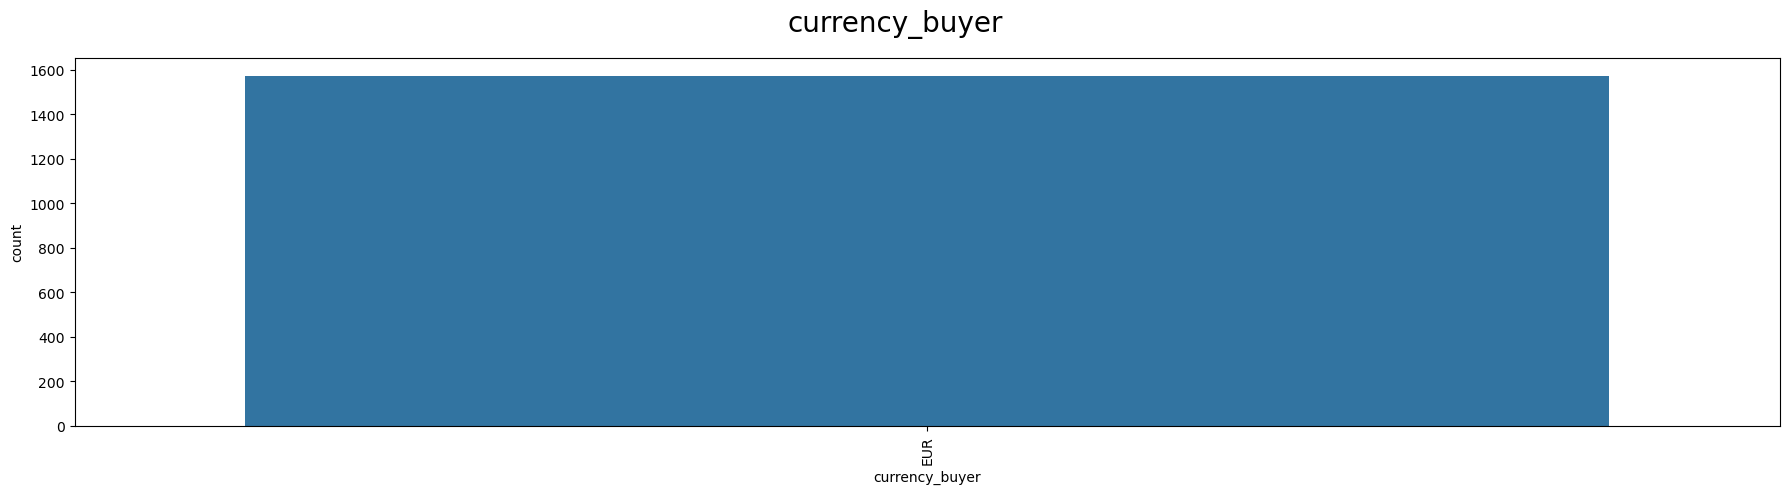

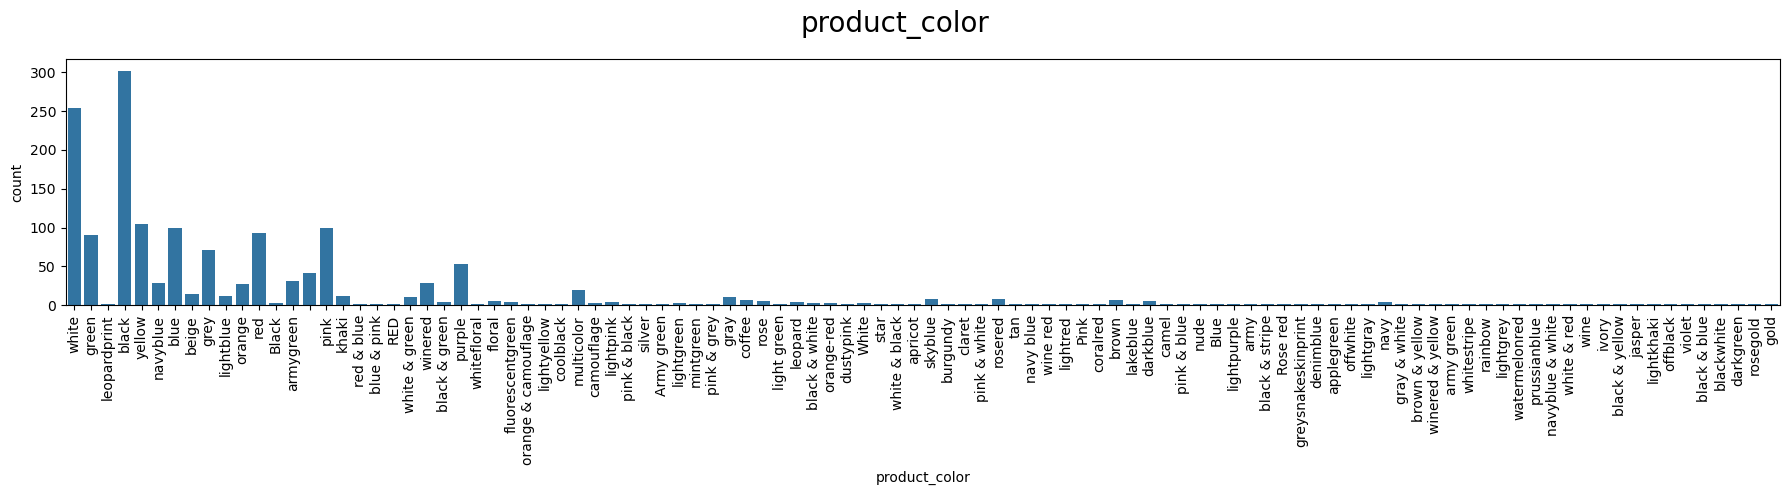

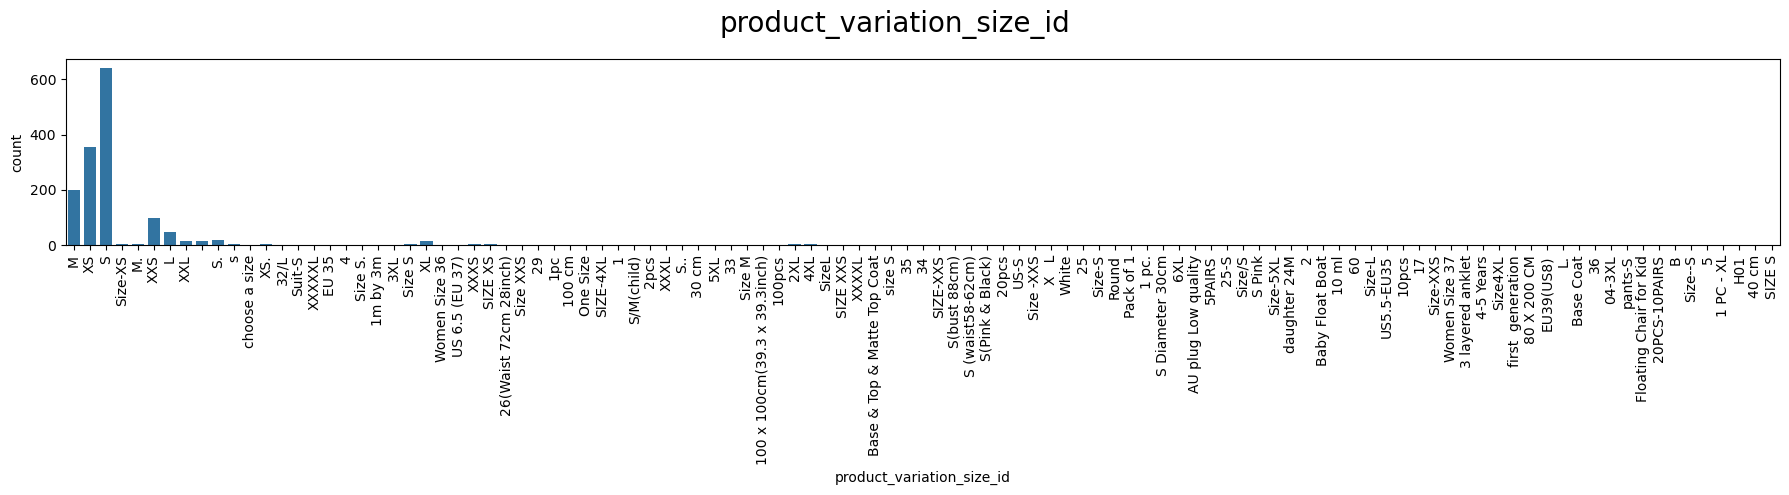

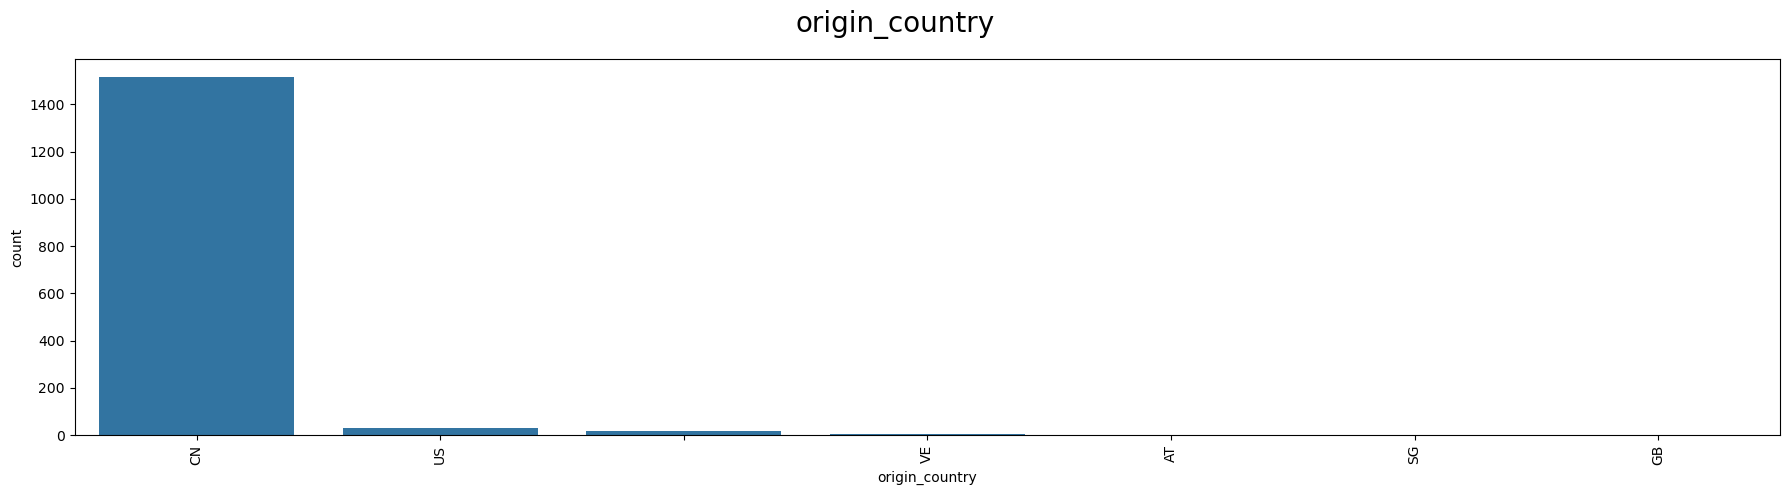

In [9]:
for col in colunas_categoricas:
    if col not in ['title', 'tags']:
        f, axes = plt.subplots(1, 1, figsize=(18, 5))
        sns.countplot(x=col, data=df_produtos)
        plt.xticks(rotation=90)
        plt.suptitle(col, fontsize=20)
        plt.tight_layout()
        plt.show()

### 4.2 Distribuição de variáveis numéricas

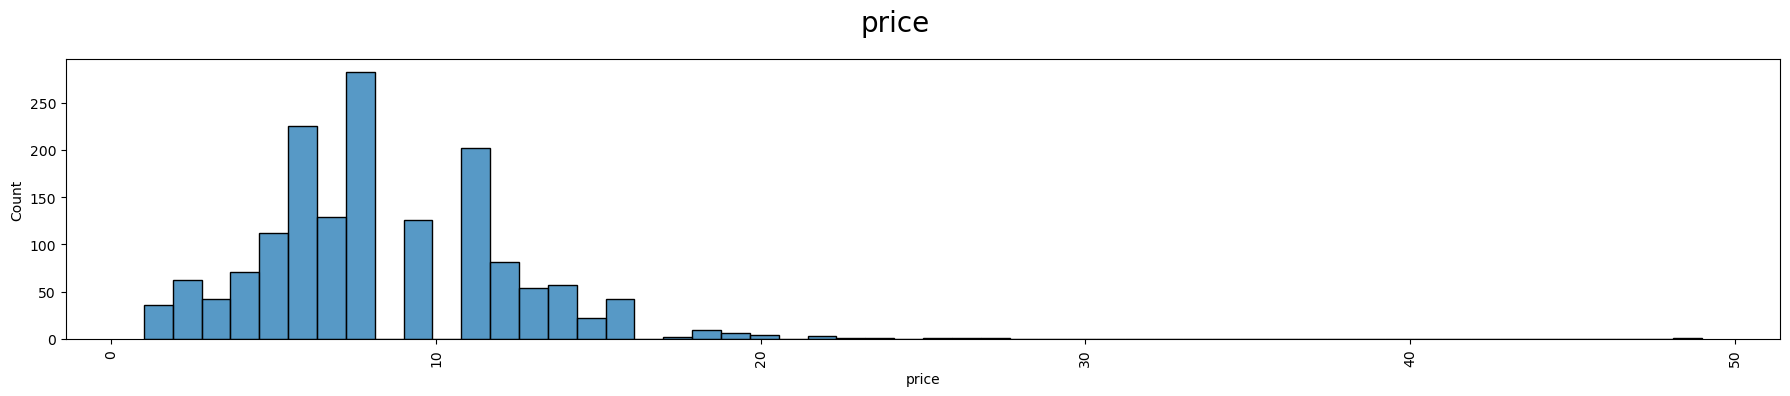

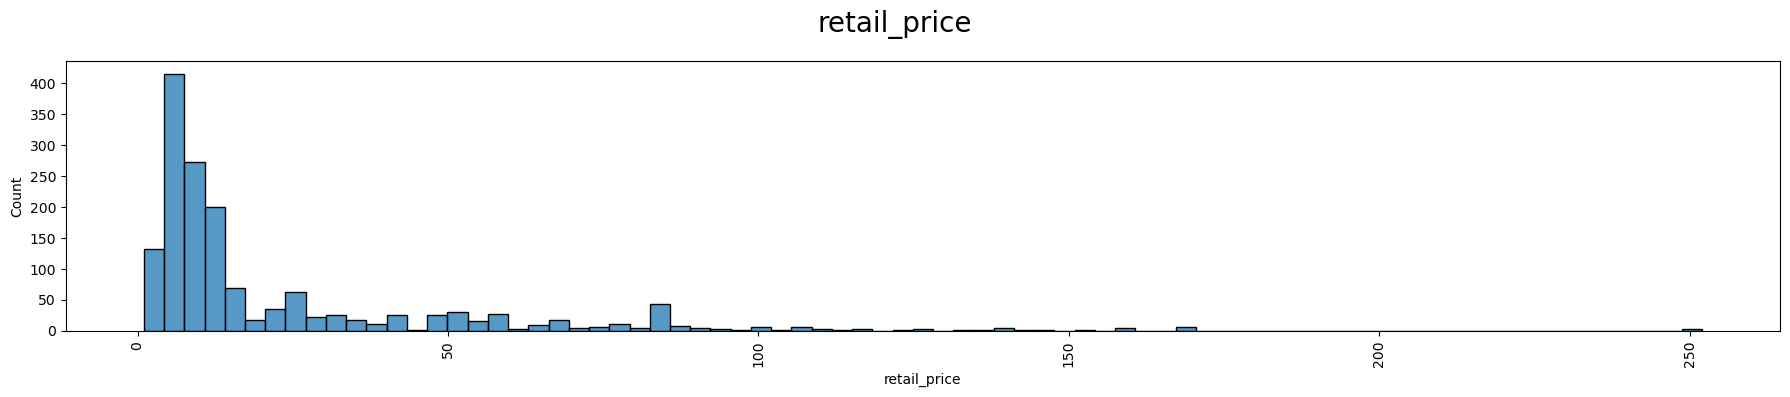

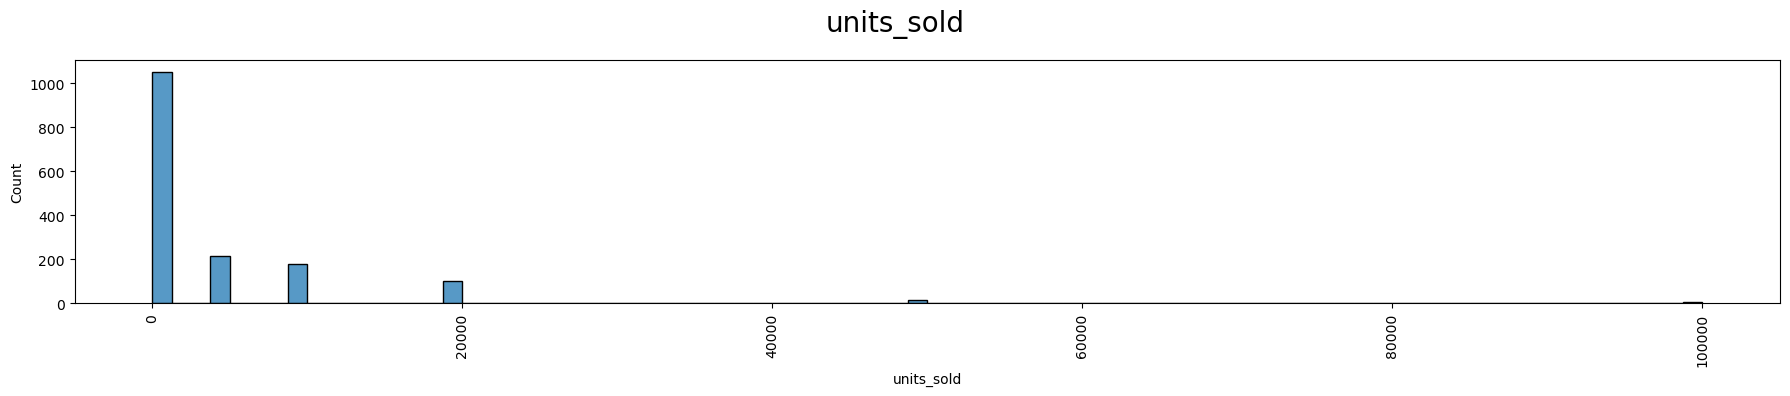

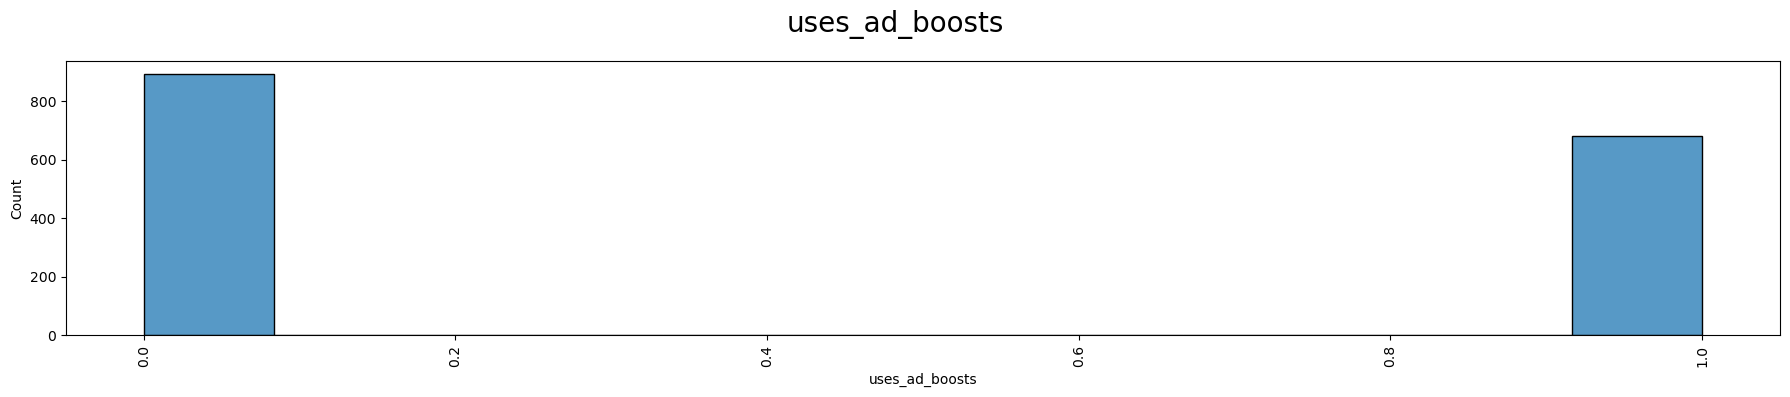

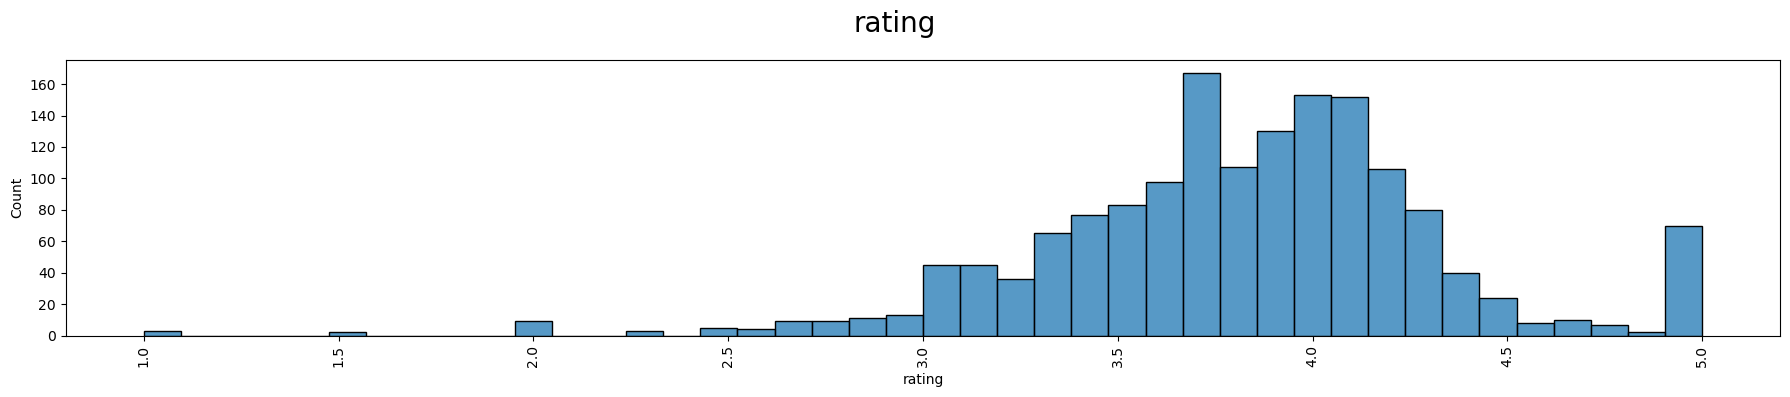

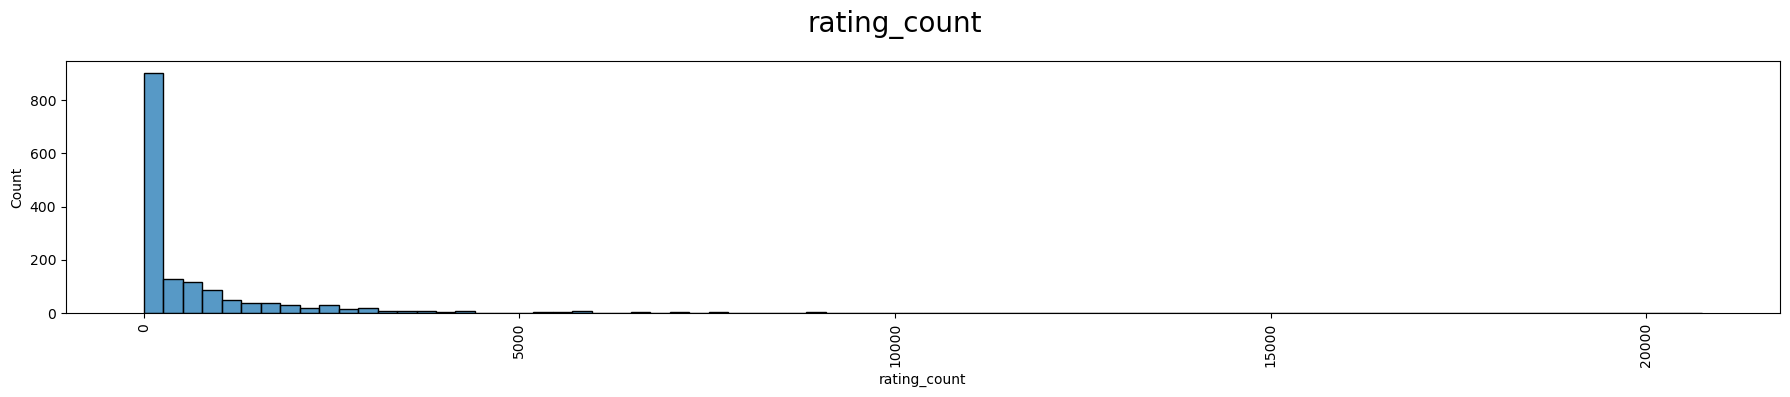

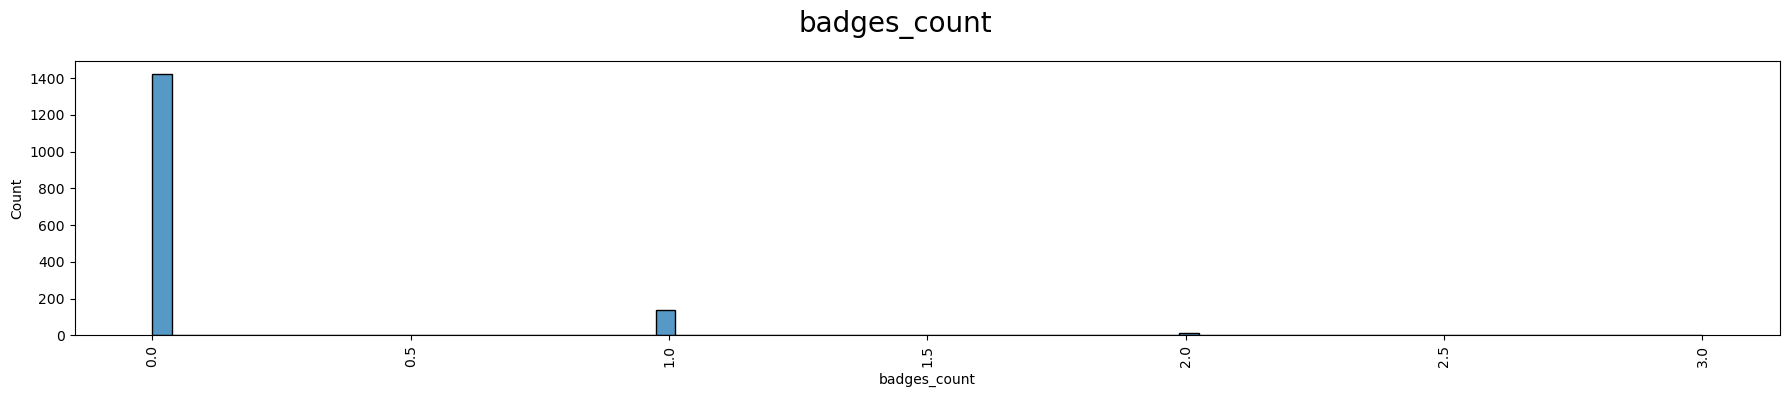

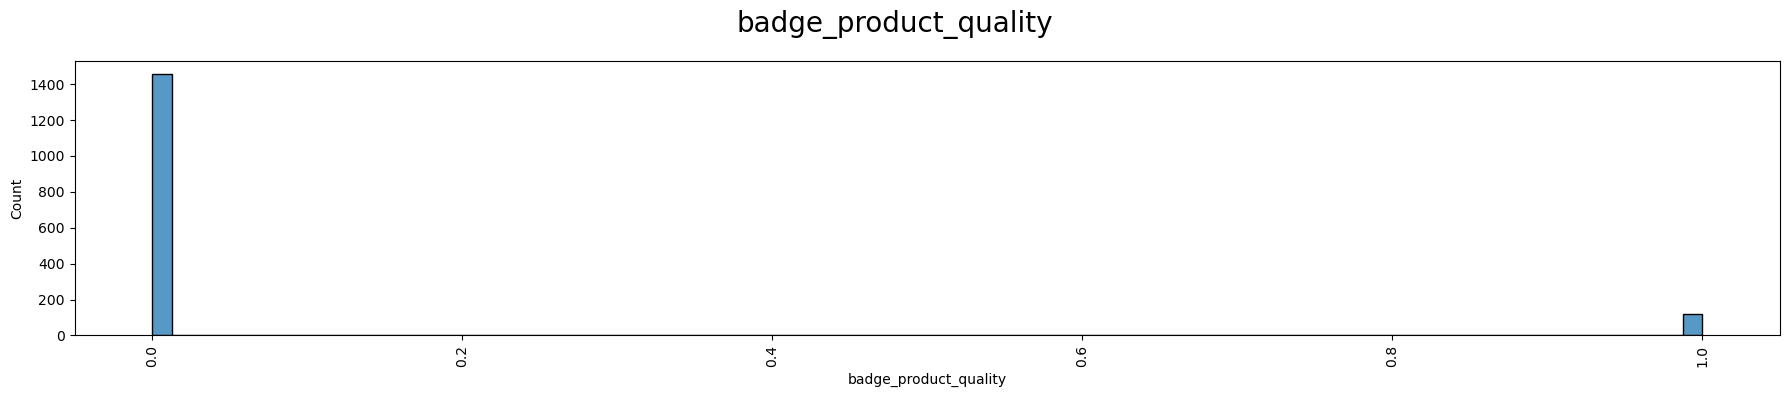

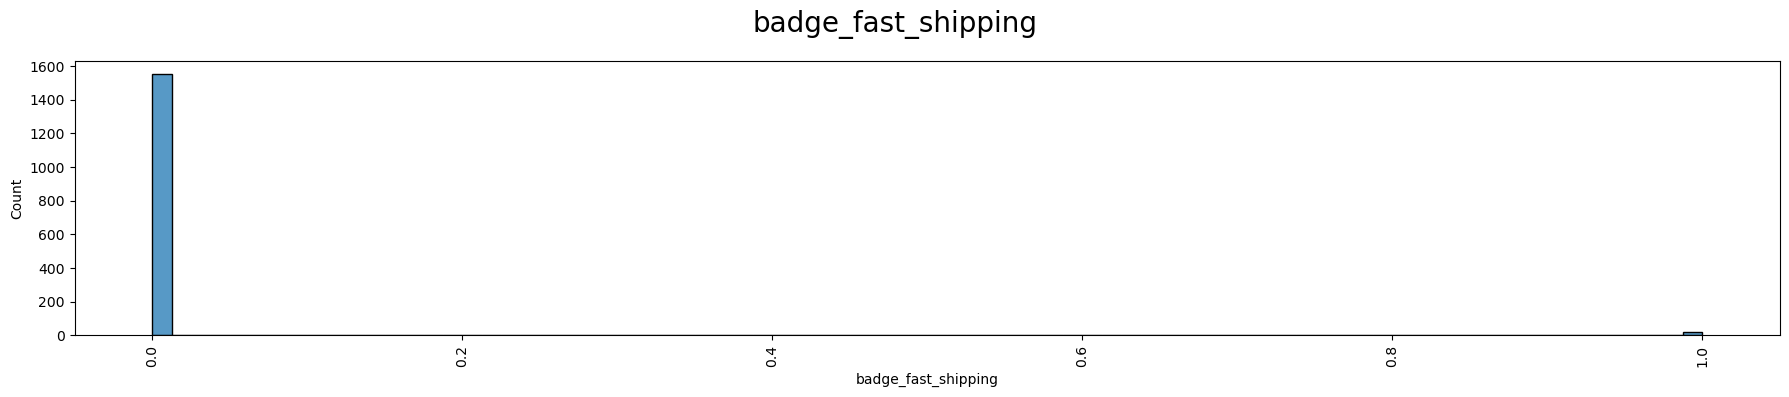

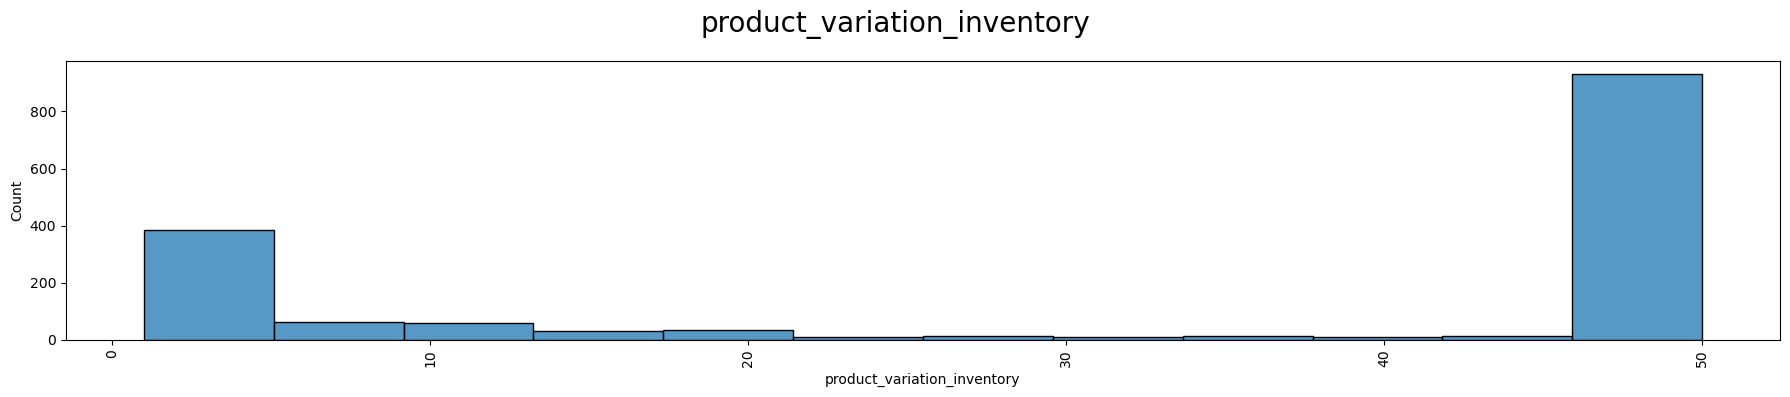

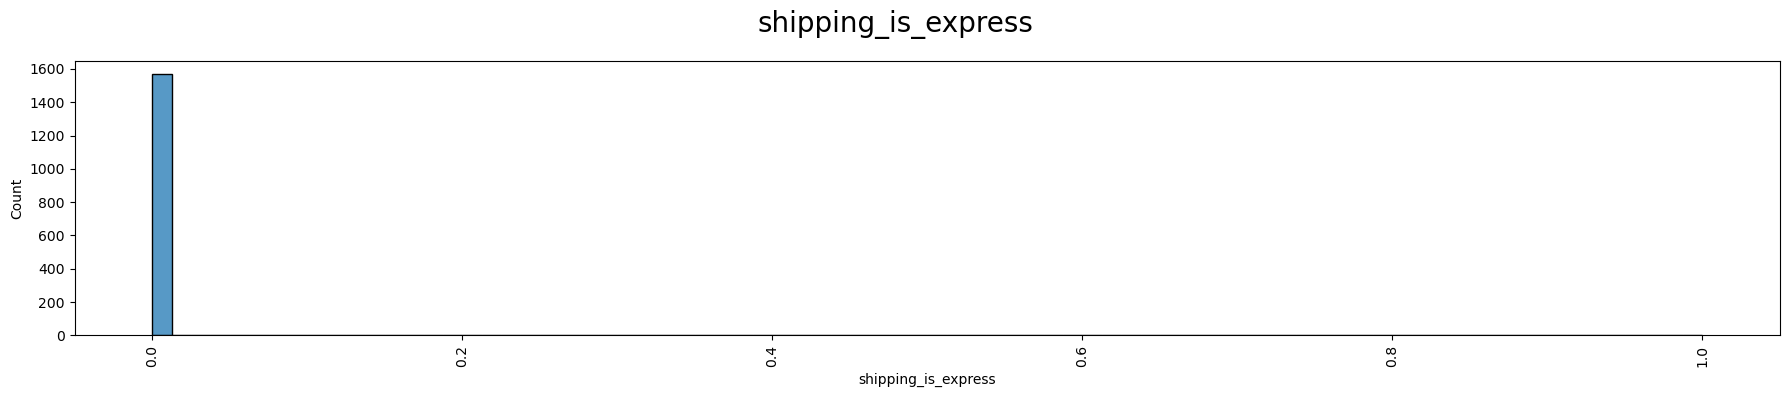

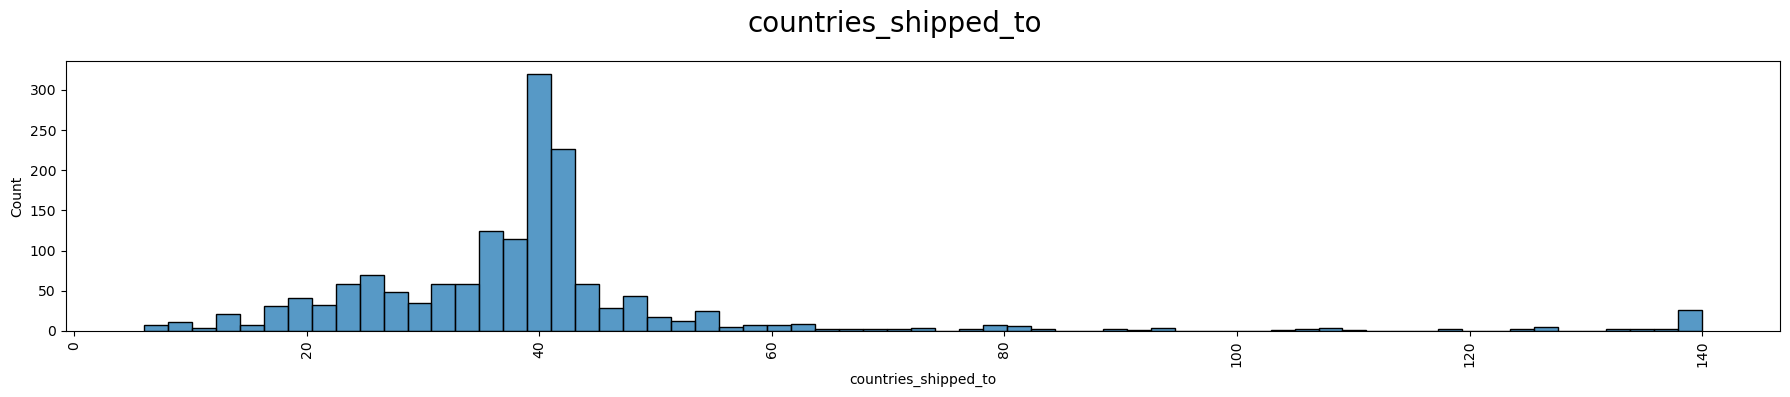

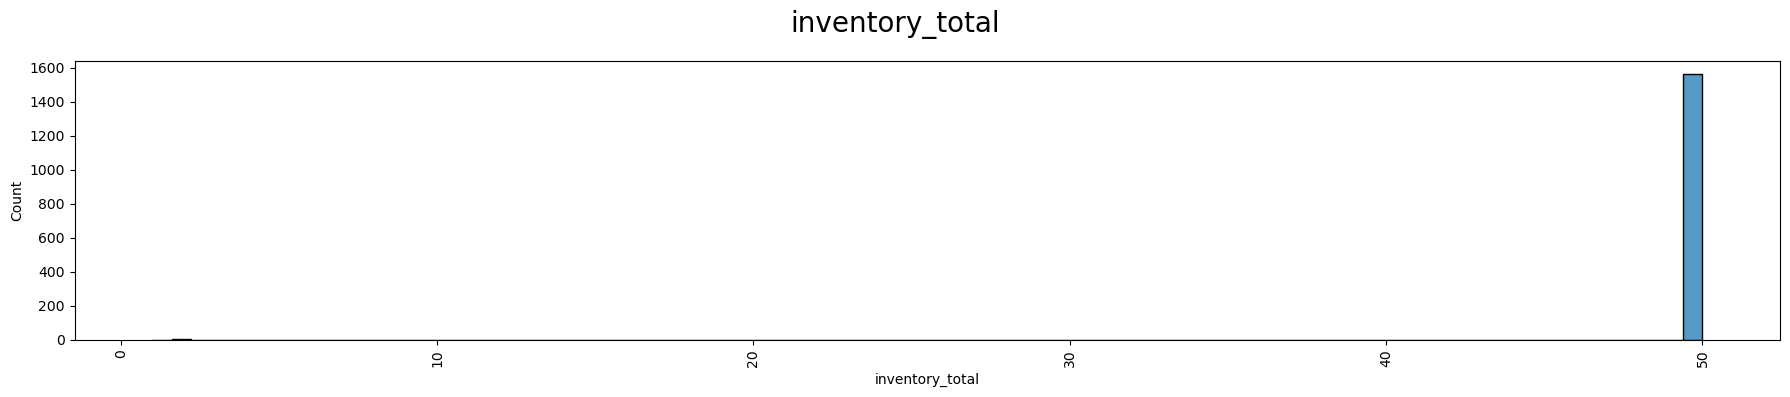

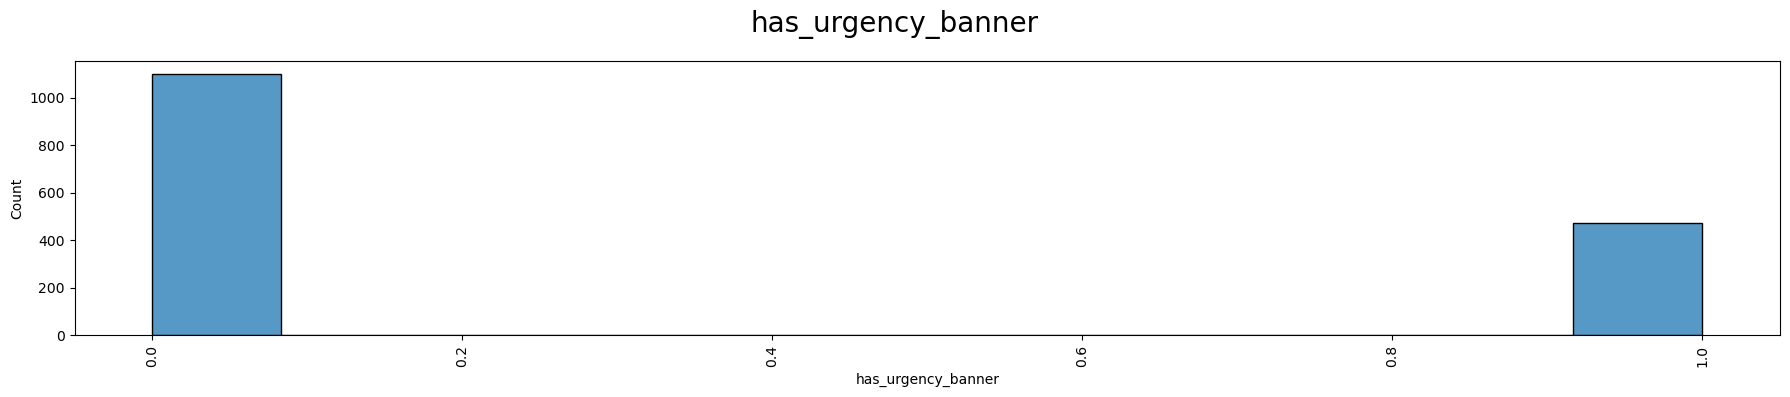

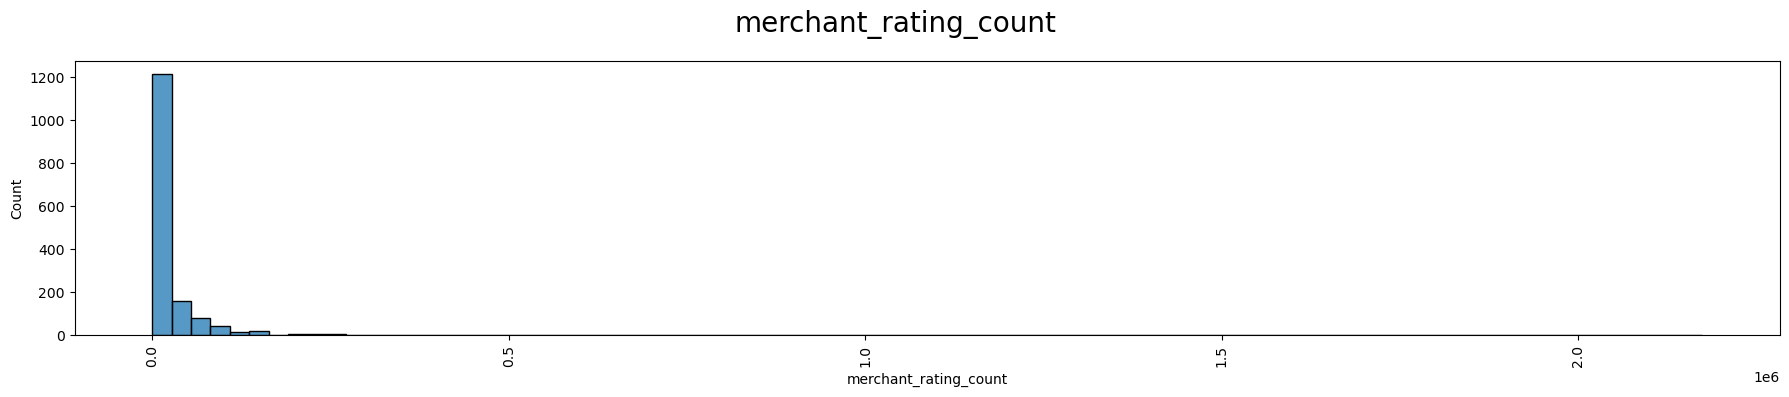

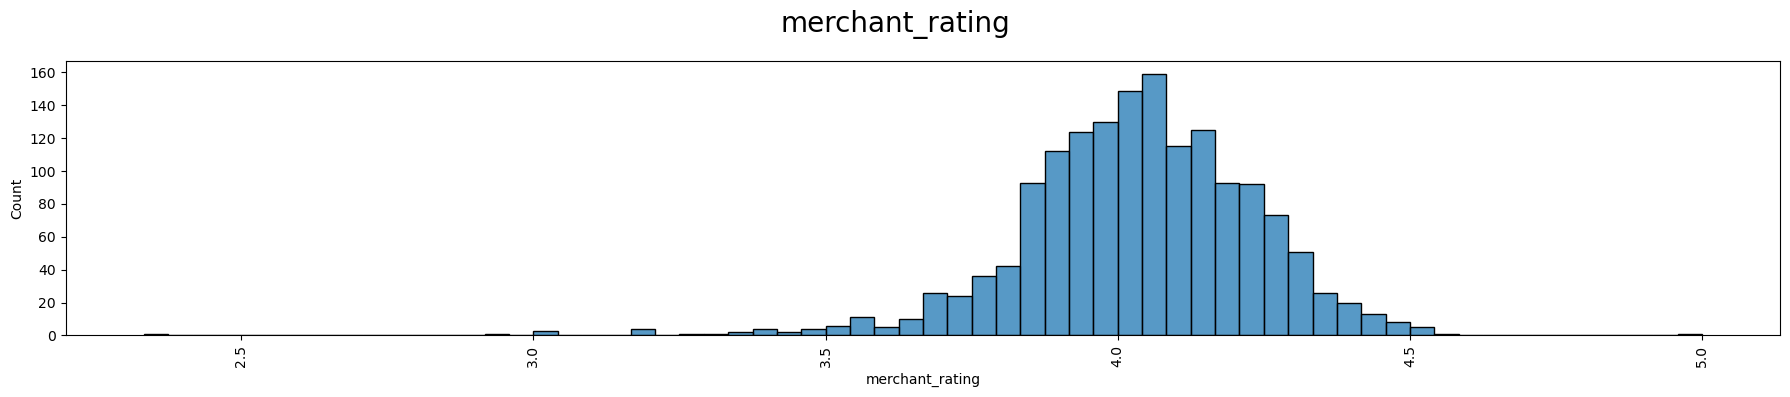

In [10]:
for col in colunas_numericas:
    f, axes = plt.subplots(1, 1, figsize=(18, 4))
    sns.histplot(x=col, data=df_produtos)
    plt.xticks(rotation=90)
    plt.suptitle(col, fontsize=20)
    plt.tight_layout()
    plt.show()

A coluna `units_sold` não é contínua assume valores discretos em escala (10, 100, 1000...). Vamos corrigir e analisar.

### 4.3 Ajuste nas colunas units_sold e tags

In [11]:
print('Distribuição de units_sold:')
print(df_produtos['units_sold'].value_counts())

Distribuição de units_sold:
units_sold
100       509
1000      405
5000      217
10000     177
20000     103
50         76
10         49
50000      17
100000      6
8           4
1           3
7           2
2           2
3           2
6           1
Name: count, dtype: int64


In [12]:
# Padronizando valores abaixo de 10 para 10 (mínimo da escala)
df_produtos.loc[df_produtos['units_sold'] < 10, 'units_sold'] = 10

print(f'Mediana de vendas: {df_produtos["units_sold"].median():,.0f}')
print(f'Média de vendas:   {df_produtos["units_sold"].mean():,.0f}')

Mediana de vendas: 1,000
Média de vendas:   4,339


Como a distribuição é assimétrica (média >> mediana), usaremos a **mediana** como referência para análise.

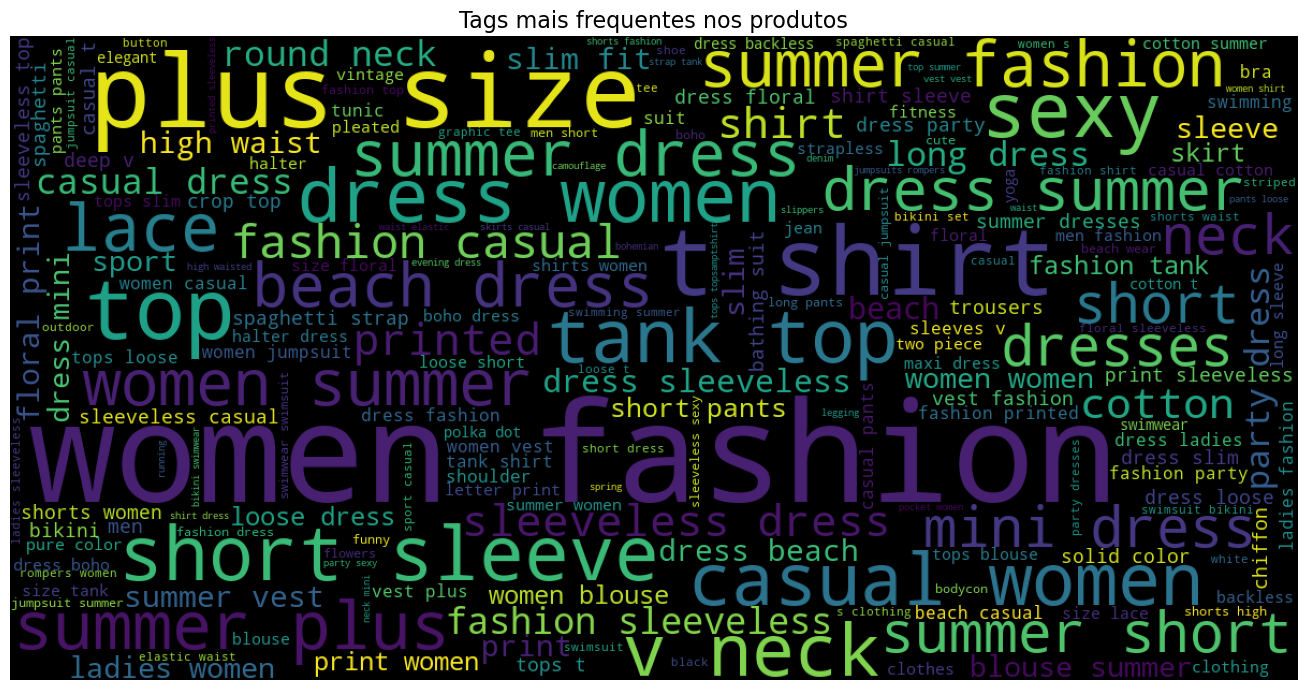

In [13]:
# Wordcloud das tags visão geral dos termos mais comuns
word_string = ' '.join(df_produtos['tags'].str.lower())
wordcloud = WordCloud(stopwords=STOPWORDS, width=1200, height=600).generate(word_string)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Tags mais frequentes nos produtos', fontsize=16)
plt.tight_layout()
plt.show()

## 5. Definindo produto de sucesso

Criamos a feature `income` (preço × unidades vendidas) e definimos `success = 1` para produtos com faturamento superior a $7.000 aproximadamente a mediana da distribuição de faturamento.

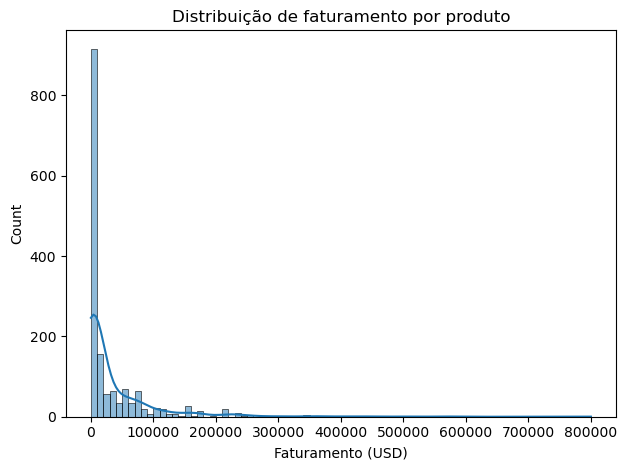

Percentis de faturamento:
  0%: $20
  11%: $369
  22%: $700
  33%: $1,100
  44%: $5,000
  56%: $8,000
  67%: $16,000
  78%: $49,800
  89%: $90,000
  100%: $800,000


In [14]:
df_produtos['income'] = df_produtos['price'] * df_produtos['units_sold']

sns.histplot(df_produtos['income'], kde=True)
plt.xlabel('Faturamento (USD)')
plt.title('Distribuição de faturamento por produto')
plt.tight_layout()
plt.show()

print('Percentis de faturamento:')
for i in np.linspace(0, 1, 10):
    print(f'  {i:.0%}: ${df_produtos["income"].quantile(i):,.0f}')

In [15]:
# Definindo threshold de sucesso em $7.000 (mediana)
df_produtos['success'] = (df_produtos['income'] > 7000).astype(int)
# Criando coluna discount uma única vez
df_produtos['discount'] = df_produtos['retail_price'] - df_produtos['price']

print(f'Produtos de sucesso (success=1): {df_produtos["success"].sum()}')
print(f'Proporção: {df_produtos["success"].mean()*100:.1f}%')

Produtos de sucesso (success=1): 764
Proporção: 48.6%


## 6. Validando as perguntas de negócio

#### 1. Produtos com maior desconto percebido vendem mais?

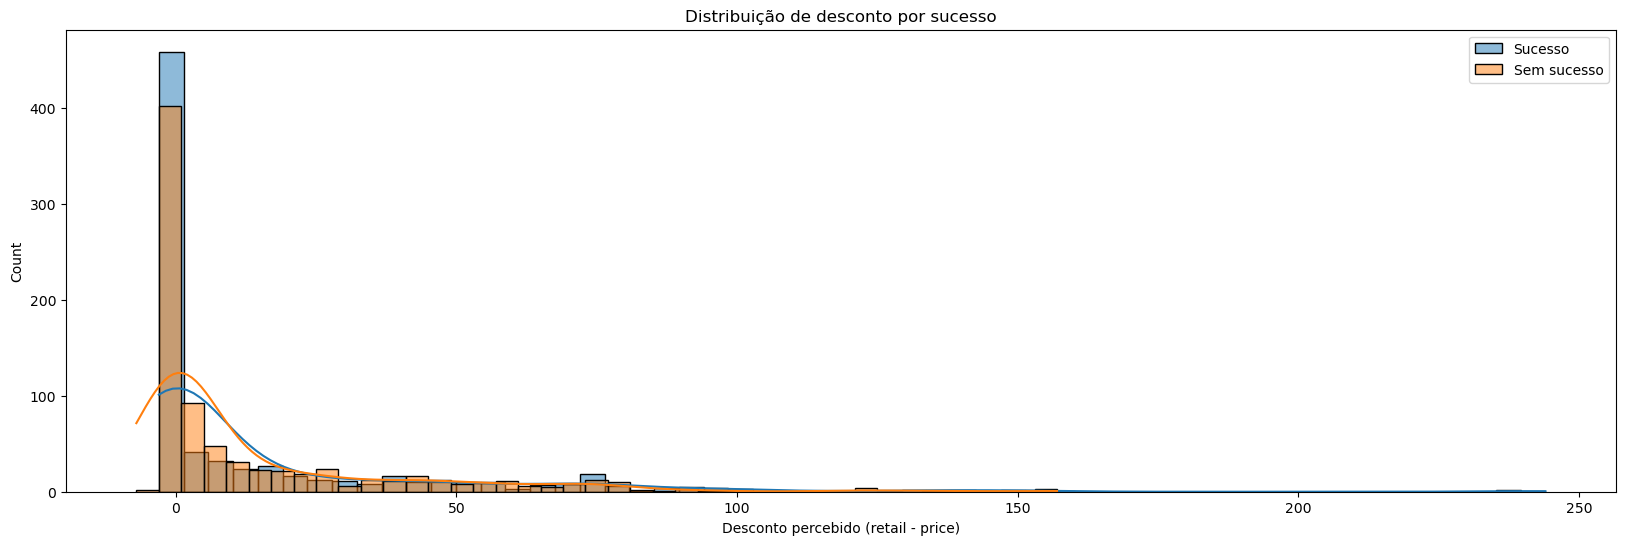

In [16]:
fig, ax = plt.subplots(figsize=(20, 6))
sns.histplot(df_produtos.loc[df_produtos['success']==1, 'discount'], label='Sucesso', kde=True)
sns.histplot(df_produtos.loc[df_produtos['success']==0, 'discount'], label='Sem sucesso', kde=True)
plt.legend()
plt.xlabel('Desconto percebido (retail - price)')
plt.title('Distribuição de desconto por sucesso')
plt.show()

#### 2. Ad boosts aumentam as vendas?

In [17]:
print('Produtos SEM sucesso uso de ad boost:')
print(df_produtos.loc[df_produtos['success']==0, 'uses_ad_boosts'].value_counts())
print('\nProdutos COM sucesso uso de ad boost:')
print(df_produtos.loc[df_produtos['success']==1, 'uses_ad_boosts'].value_counts())

Produtos SEM sucesso uso de ad boost:
uses_ad_boosts
0    441
1    368
Name: count, dtype: int64

Produtos COM sucesso uso de ad boost:
uses_ad_boosts
0    451
1    313
Name: count, dtype: int64


A maioria dos produtos de sucesso **não** utiliza ad boost qualidade do produto parece ser mais determinante que publicidade paga.

#### 3. Avaliações melhores aumentam vendas?

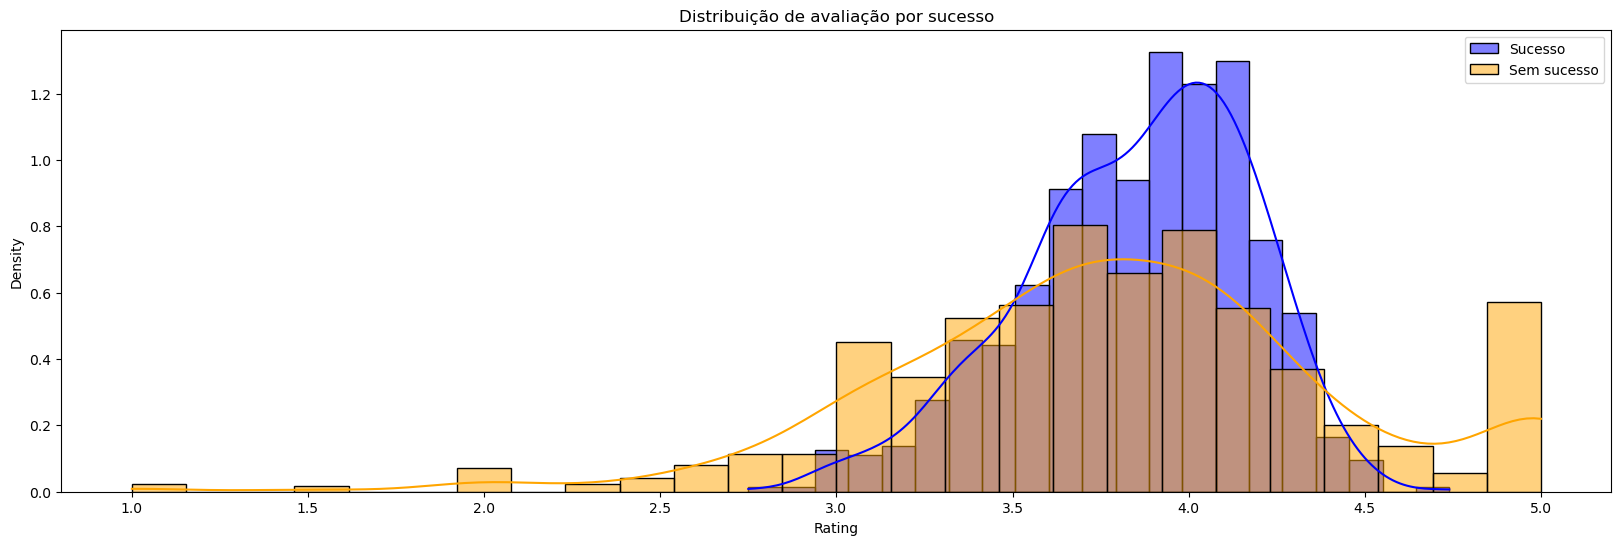

In [18]:
fig, ax = plt.subplots(figsize=(20, 6))
sns.histplot(df_produtos.loc[df_produtos['success']==1, 'rating'], label='Sucesso', color='blue', kde=True, stat='density')
sns.histplot(df_produtos.loc[df_produtos['success']==0, 'rating'], label='Sem sucesso', color='orange', kde=True, stat='density')
plt.legend()
plt.xlabel('Rating')
plt.title('Distribuição de avaliação por sucesso')
plt.savefig('distribuicao_avaliacao_por_sucesso.png', dpi=150, bbox_inches='tight')

plt.show()

Produtos com melhores avaliações tendem a vender mais **prova social é um driver relevante de conversão**.

#### 4. Badges importam?

In [19]:
print('Badges count por sucesso:')
print(df_produtos.groupby(['success','badges_count']).count()[['title']].pivot_table(index='success', columns='badges_count').fillna(0))

Badges count por sucesso:
              title                
badges_count      0     1    2    3
success                            
0             753.0  48.0  8.0  0.0
1             669.0  90.0  3.0  2.0


In [20]:
print('Badge de qualidade por sucesso:')
print(df_produtos.groupby(['success','badge_product_quality']).count()[['title']].pivot_table(index='success', columns='badge_product_quality').fillna(0))

Badge de qualidade por sucesso:
                       title      
badge_product_quality      0     1
success                           
0                      770.0  39.0
1                      686.0  78.0


In [21]:
print('Badge de envio rápido por sucesso:')
print(df_produtos.groupby(['success','badge_fast_shipping']).count()[['title']].pivot_table(index='success', columns='badge_fast_shipping').fillna(0))

Badge de envio rápido por sucesso:
                     title      
badge_fast_shipping      0     1
success                         
0                    795.0  14.0
1                    758.0   6.0


Badges isoladamente não parecem determinar sucesso o impacto é mais sutil e combinado com outros fatores.

#### 5. Quantidade de tags auxilia vendas?

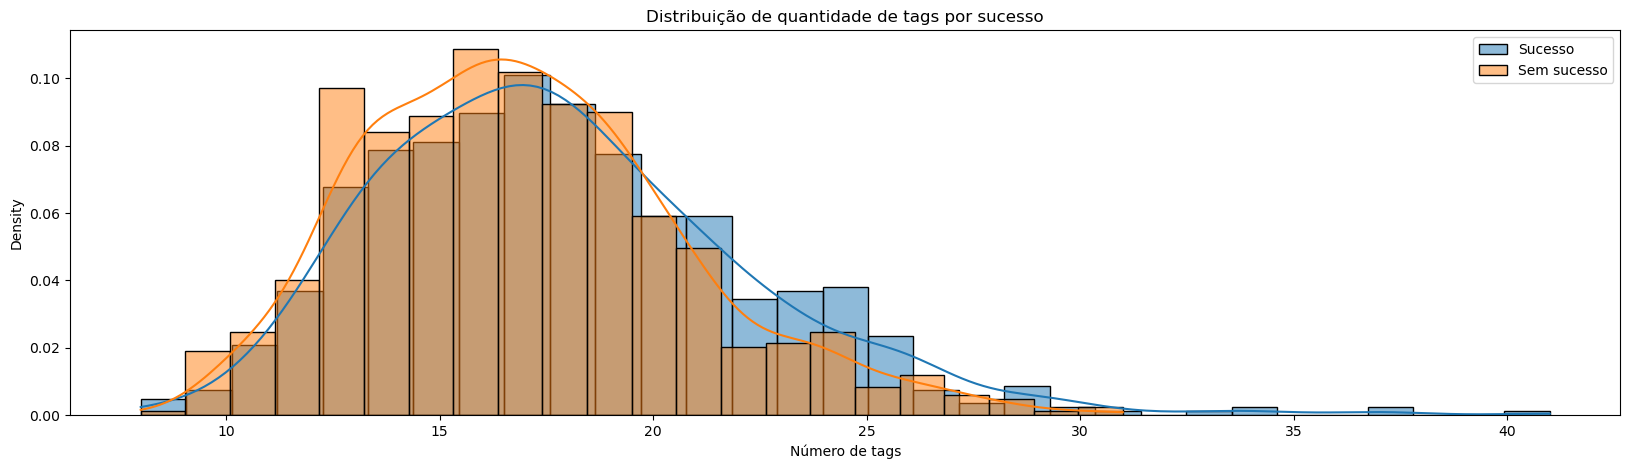

In [22]:
df_produtos['tags_count'] = df_produtos['tags'].apply(lambda x: len(x.split(',')))

fig, ax = plt.subplots(figsize=(20, 5))
sns.histplot(df_produtos.loc[df_produtos['success']==1, 'tags_count'], label='Sucesso', kde=True, stat='density')
sns.histplot(df_produtos.loc[df_produtos['success']==0, 'tags_count'], label='Sem sucesso', kde=True, stat='density')
plt.legend()
plt.xlabel('Número de tags')
plt.title('Distribuição de quantidade de tags por sucesso')
plt.savefig('distribuicao_quantidade_de_tags.png', dpi=150, bbox_inches='tight')
plt.show()

Produtos com mais tags tendem a vender mais maior discoverabilidade na plataforma.

#### 6. Tags associadas a produtos de sucesso

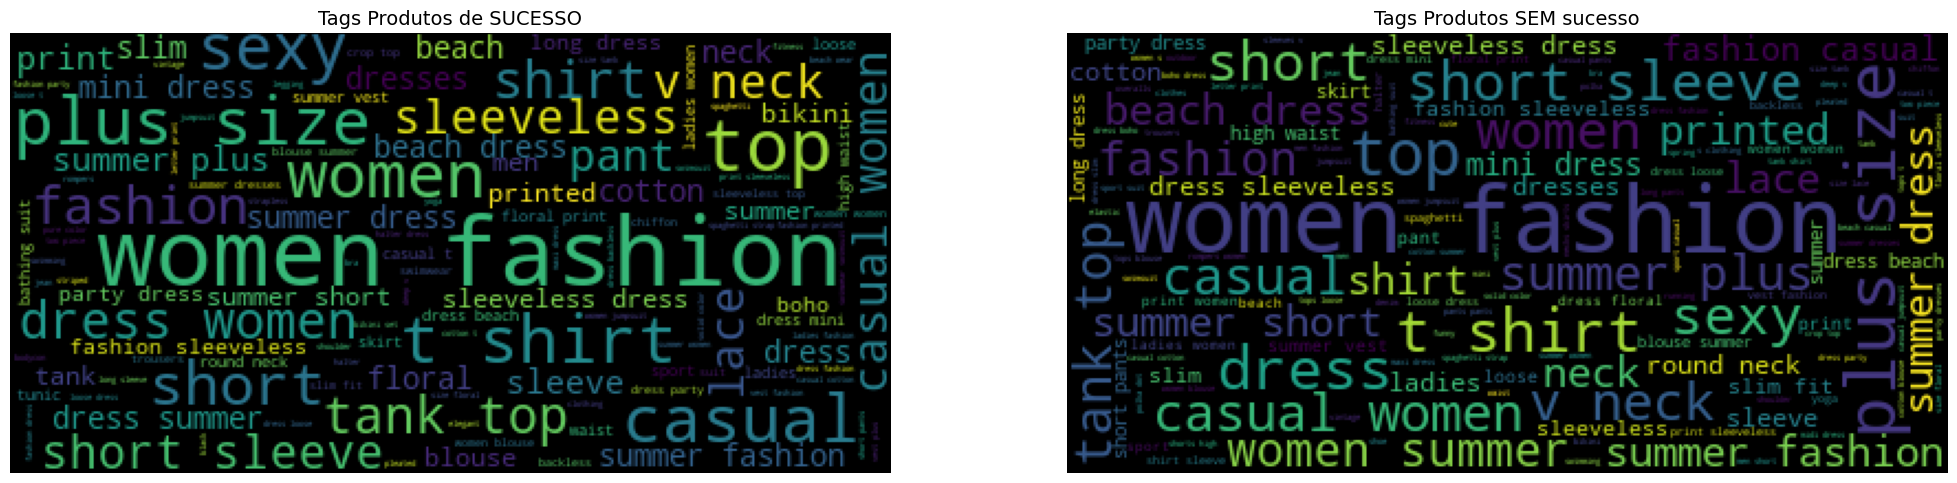

In [23]:
df_sucesso = df_produtos.loc[df_produtos['success']==1]
df_falha = df_produtos.loc[df_produtos['success']==0]

word_str_s = ' '.join(df_sucesso['tags'].str.lower())
word_str_f = ' '.join(df_falha['tags'].str.lower())

wc_s = WordCloud(stopwords=STOPWORDS).generate(word_str_s)
wc_f = WordCloud(stopwords=STOPWORDS).generate(word_str_f)

fig, ax = plt.subplots(1, 2, figsize=(25, 10))
ax[0].imshow(wc_s); ax[0].set_title('Tags Produtos de SUCESSO', fontsize=14); ax[0].axis('off')
ax[1].imshow(wc_f); ax[1].set_title('Tags Produtos SEM sucesso', fontsize=14); ax[1].axis('off')
plt.savefig('tags_sucesso.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
tags_s = []
for t in df_sucesso['tags'].values:
    tags_s += t.split(',')
print('Top 5 tags em produtos de sucesso:')
print(pd.Series(tags_s).value_counts().head(5))

tags_f = []
for t in df_falha['tags'].values:
    tags_f += t.split(',')
print('\nTop 5 tags em produtos sem sucesso:')
print(pd.Series(tags_f).value_counts().head(5))

Top 5 tags em produtos de sucesso:
Women's Fashion    665
Summer             580
Fashion            527
Women              504
Casual             429
Name: count, dtype: int64

Top 5 tags em produtos sem sucesso:
Summer             741
Women's Fashion    650
Fashion            555
Casual             476
Women              457
Name: count, dtype: int64


#### 7. Shipping analysis

In [25]:
print('Shipping express por sucesso:')
print(df_produtos.groupby(['success','shipping_is_express']).count()[['title']].pivot_table(index='success', columns='shipping_is_express').fillna(0))

Shipping express por sucesso:
                     title     
shipping_is_express      0    1
success                        
0                    807.0  2.0
1                    762.0  2.0


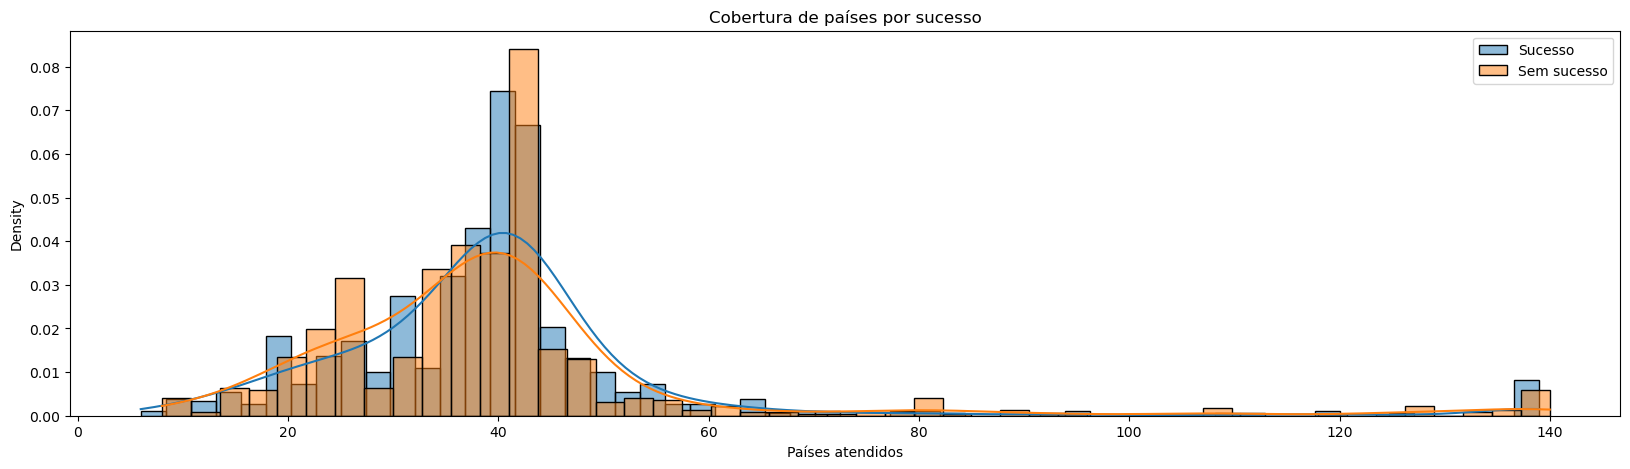

In [26]:
fig, ax = plt.subplots(figsize=(20, 5))
sns.histplot(df_produtos.loc[df_produtos['success']==1, 'countries_shipped_to'], label='Sucesso', kde=True, stat='density')
sns.histplot(df_produtos.loc[df_produtos['success']==0, 'countries_shipped_to'], label='Sem sucesso', kde=True, stat='density')
plt.legend()
plt.xlabel('Países atendidos')
plt.title('Cobertura de países por sucesso')
plt.savefig('shipping_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Machine Learning Random Forest Classifier

In [27]:
colunas_modelo = [
    'price', 'retail_price', 'uses_ad_boosts', 'rating', 'badges_count',
    'badge_product_quality', 'badge_fast_shipping', 'product_variation_inventory',
    'shipping_is_express', 'countries_shipped_to', 'inventory_total',
    'has_urgency_banner', 'merchant_rating', 'discount', 'tags_count'
]

X = df_produtos[colunas_modelo]
y = df_produtos['success']

# random_state=42 para reprodutibilidade
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f'Treino: {X_train.shape[0]} produtos')
print(f'Teste:  {X_test.shape[0]} produtos')
print(f'Taxa de sucesso no treino: {y_train.mean()*100:.1f}%')

Treino: 1101 produtos
Teste:  472 produtos
Taxa de sucesso no treino: 49.5%


In [28]:
# GridSearch com parâmetros realistas para Random Forest
param_grid = [
    {'n_estimators': [100, 200, 300], 'max_features': [2, 4, 6, 8]},
    {'bootstrap': [False], 'n_estimators': [100, 200], 'max_features': [2, 4, 6]},
]

forest_clf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    forest_clf, param_grid, cv=5,
    return_train_score=True, n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print(f'\nMelhores parâmetros: {grid_search.best_params_}')

Fitting 5 folds for each of 18 candidates, totalling 90 fits

Melhores parâmetros: {'max_features': 6, 'n_estimators': 200}


In [29]:
rf_model = grid_search.best_estimator_
y_pred = rf_model.predict(X_test)

print('Random Forest — Classification Report')
print(classification_report(y_test, y_pred))
print('Matriz de confusão:')
print(confusion_matrix(y_test, y_pred))
print(f'ROC-AUC: {roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]):.4f}')

Random Forest — Classification Report
              precision    recall  f1-score   support

           0       0.77      0.77      0.77       253
           1       0.74      0.74      0.74       219

    accuracy                           0.76       472
   macro avg       0.76      0.76      0.76       472
weighted avg       0.76      0.76      0.76       472

Matriz de confusão:
[[196  57]
 [ 57 162]]
ROC-AUC: 0.8428


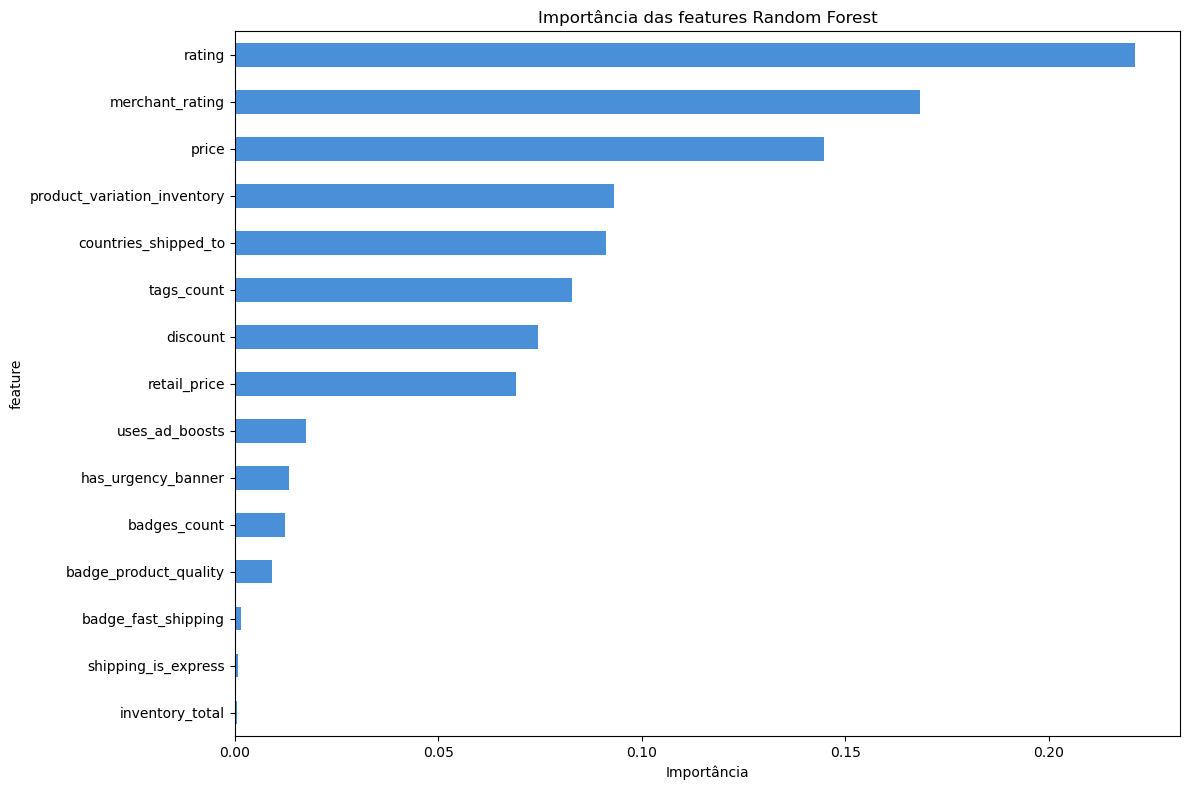

In [30]:
# Importância das features
feature_importances = pd.DataFrame({'feature': X.columns, 'importancia': rf_model.feature_importances_}).sort_values('importancia', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
feature_importances.plot(kind='barh', x='feature', y='importancia', ax=ax, legend=False, color='#4A90D9')
plt.title('Importância das features Random Forest')
plt.xlabel('Importância')
plt.tight_layout()
plt.savefig('feature_importance_wish.png', dpi=150, bbox_inches='tight')
plt.show()

### Análise SHAP Explicabilidade do modelo

SHAP (SHapley Additive exPlanations) explica a contribuição de cada feature para cada previsão individual vai além da importância agregada e mostra a **direção** do impacto.

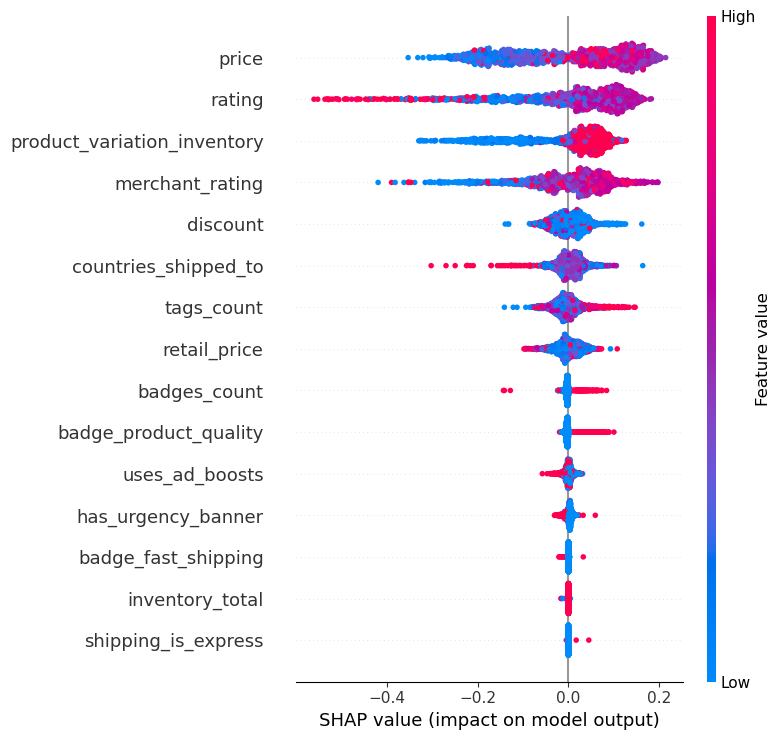

<Figure size 640x480 with 0 Axes>

In [31]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(X)

shap.summary_plot(shap_values[:,:,1], X)
plt.savefig('SHAP.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Conclusões

Este projeto identificou os principais fatores que determinam o sucesso de produtos de verão na Wish.

**Principais descobertas:**

1. **Rating e volume de avaliações** são os drivers mais fortes de vendas prova social é essencial
2. **Desconto percebido** (diferença entre retail_price e price) influencia positivamente a conversão
3. **Tags bem escolhidas** e em maior quantidade aumentam a discoverabilidade do produto
4. **Ad boosts** têm efeito positivo mas não determinante qualidade supera publicidade
5. **Badges** contribuem para confiança mas não garantem vendas sozinhos
6. **Cobertura geográfica** (países atendidos) correlaciona com sucesso maior alcance, mais vendas

**Para vendedores na Wish:** invista primeiro em produto de qualidade e experiência do cliente (ratings), precifique competitivamente em relação ao retail price, e use tags estratégicas para alcance orgânico.

## 9. Exportando o modelo para deploy

In [32]:
joblib.dump(rf_model, 'modelo_wish_success.pkl')
joblib.dump(colunas_modelo, 'colunas_wish.pkl')

print('Arquivos salvos:')
print('  modelo_wish_success.pkl')
print('  colunas_wish.pkl')

Arquivos salvos:
  modelo_wish_success.pkl
  colunas_wish.pkl
